### Priyanshu Kumar Singh

Objectiv = CAR PRICE PREDICTION USING ML

# TASK THREE OF OASIS INFOBYTE INTERNSHIP

In [11]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings


In [12]:
# Load dataset


In [13]:
df = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')

# Inspect dataset
print(df.info())
print(df)

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 515.2 KB
None
                                     name  year  selling_price  km_driven  \
0                           Maruti 800 AC  2007          60000      70000   
1                Maruti Wagon R LXI Minor  2007         135000      50000   
2                    Hyundai Verna 1.6 SX  2012         600000     100000   
3                  Datsun RediGO T Option  2017         250000      46000   
4                   Honda Amaze VX i-DTEC  2014

In [14]:
#here, we find that the dataset has 4340 rows and 8 columns

# Data Cleaning

Handling Null Values, by identifying missing values across all columns and handle them appropriately

In [15]:
# Check missing counts
print(df.isnull().sum())

# Drop rows containing missing values or impute numerical/categorical columns
df = df.dropna()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [16]:
#by using isnull(), we get to see whether any missing values are there in the dataset

Removing Duplicates:

In [17]:
# Drop redundant rows
df = df.drop_duplicates().reset_index(drop=True)

# Standardizing text across all string columns to resolve formatting issues like "Petrol" vs. "petrol"

In [20]:
categorical_cols = df.select_dtypes(include=['object','str']).columns

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()
    print(f"Unique in {col}: {df[col].unique()}")

Unique in name: <ArrowStringArray>
[                               'maruti 800 ac',
                     'maruti wagon r lxi minor',
                         'hyundai verna 1.6 sx',
                       'datsun redigo t option',
                        'honda amaze vx i-dtec',
                         'maruti alto lx bsiii',
                    'hyundai xcent 1.2 kappa s',
                     'tata indigo grand petrol',
                     'hyundai creta 1.6 vtvt s',
                     'maruti celerio green vxi',
 ...
                    'honda amaze s petrol bsiv',
         'hyundai santro xing xs erlx euro iii',
                            'hyundai santro at',
           'ford endeavour 2.2 titanium at 4x2',
                   'chevrolet spark 1.0 lt bs3',
                             'maruti swift ldi',
                                 'tata nano xm',
                 'mahindra verito 1.5 d6 bsiii',
 'toyota innova 2.5 vx (diesel) 8 seater bs iv',
                   'hyundai i

In [36]:
#here, we performed standardization of the keywords, like Petrol vs petrol, so as to resolve any conflicting errors

Calculating Car Age from Year Column:

In [25]:
from datetime import datetime

# Safely check if 'year' exists, or if 'car_age' was already created
if 'year' in df.columns:
    current_year = datetime.now().year
    df['car_age'] = current_year - pd.to_numeric(df['year'], errors='coerce')
    df.drop(columns=['year'], inplace=True)
    print("car_age created successfully!")
elif 'car_age' in df.columns:
    print("car_age column already exists.")
else:
    print("Neither 'year' nor 'car_age' found. Reload the dataset if needed.")

car_age column already exists.


In [26]:
# Extraction of brand name:

In [27]:
if 'name' in df.columns:
    df['brand'] = df['name'].apply(lambda x: str(x).split()[0])
    df.drop(columns=['name'], inplace=True)
    print("Brand column created successfully!")
elif 'brand' in df.columns:
    print("Brand column already exists.")

Brand column created successfully!


In [28]:
#Correlation Heatmap and One-Hot Encoding

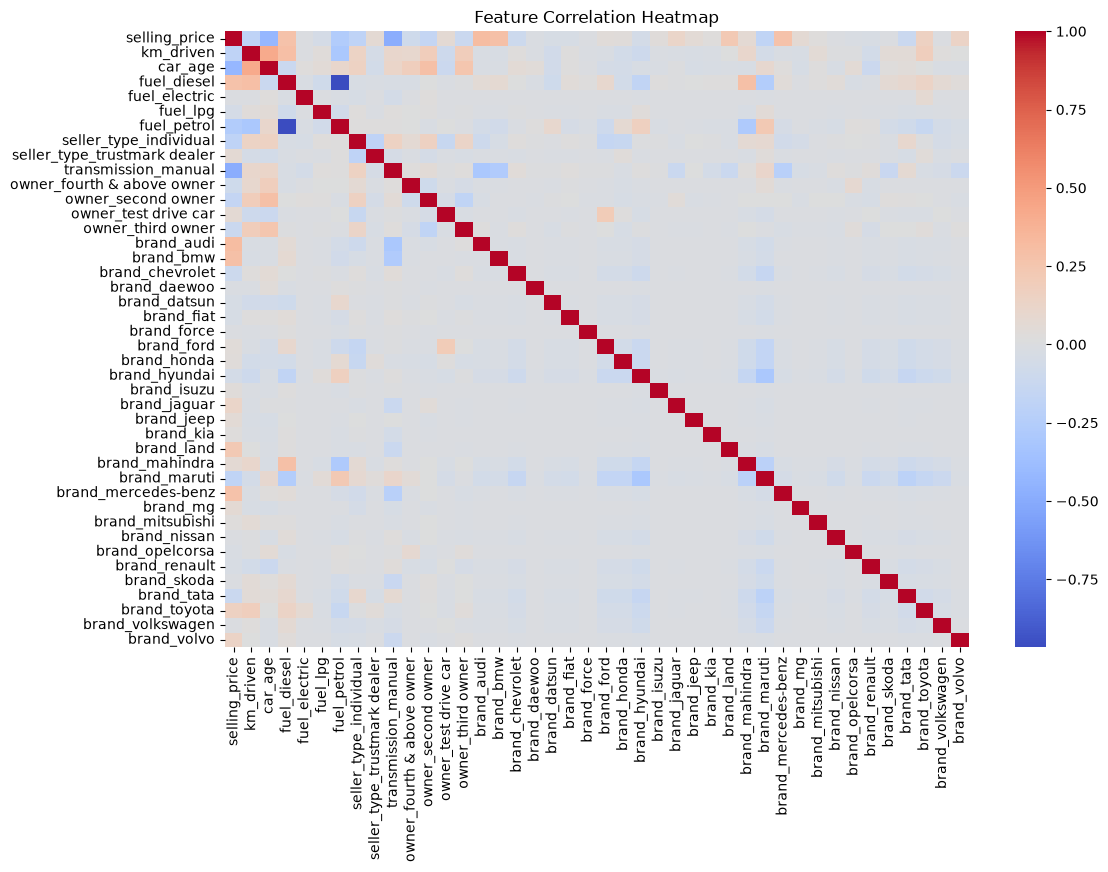

In [29]:
# Conversion of categorical features into dummy/indicator variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Generate Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [37]:
#here, by using sns and matplotlib.pyplot, we get to see the the correlation heatmap.

# Training/Testing Split and Model Training

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure target variable uses lowercased name
X = df_encoded.drop(columns=['selling_price'])
y = pd.to_numeric(df_encoded['selling_price'], errors='coerce')

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Train and evaluate models
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2 Score': r2})

# Display evaluation metrics
results_df = pd.DataFrame(results)
print(results_df)

                     Model            MAE           RMSE  R2 Score
0        Linear Regression  185413.760184  380273.354725  0.551093
1  Random Forest Regressor  158918.379218  365567.412752  0.585142
2        Gradient Boosting  157053.915373  376551.894280  0.559837


In [38]:
# The evaluation of the MAE, RMSE, and R^2 scores, for the three models-(Linear Regression, Random Forest, and Gradient Boosting, we get these following observation:

In [39]:
#The MAE, RMSE, and R^2 scores of the Linear Regression Model are maximum.

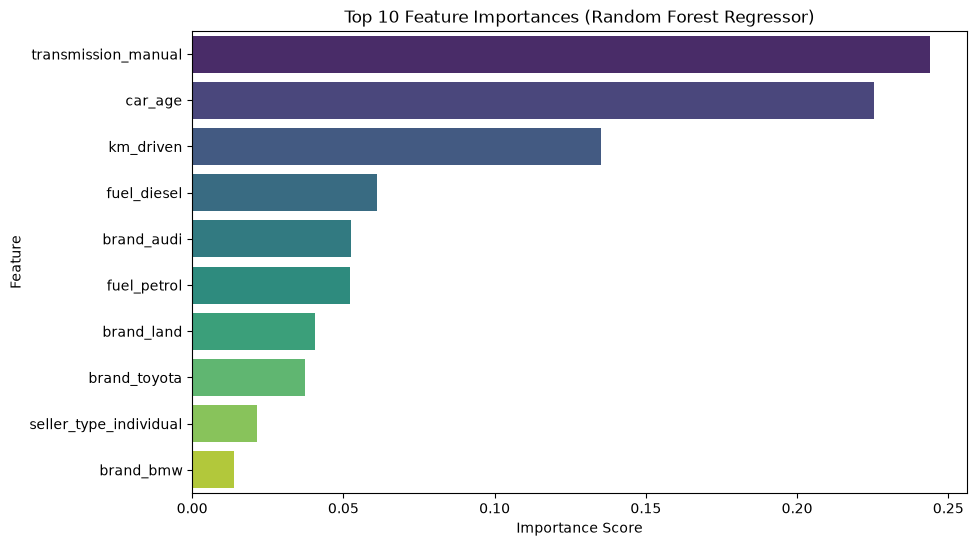

In [33]:
# Extract feature importances from the best model (Random Forest)
rf_model = models["Random Forest Regressor"]
importances = rf_model.feature_importances_

# Create a DataFrame for visualization
feature_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot top 10 most influential features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), hue ='Feature', legend=False, palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest Regressor)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

In [40]:
#The plot above, represents top 10 influentioal features

# Conclusion:

 Project Summary & Key Insights
1. Model Evaluation: The Random Forest Regressor achieved the best overall performance with an $R^2$ score of approximately 0.585, outperforming Linear Regression and Gradient Boosting.
2. Key Feature Drivers:
  Transmission Type: Manual vs. Automatic transmission serves as the strongest predictor of selling price.
  Vehicle Age and Mileage: 'car_age' and 'km_driven' are major factors in price depreciation.
   Fuel Type and Brand: Vehicles running on 'fuel_diesel' and premium brands ('brand_audi', 'brand_land', 'brand_bmw') maintain higher resale values.